In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../../data/raw/train.csv")
print("Load data successfully!")

Load data successfully!


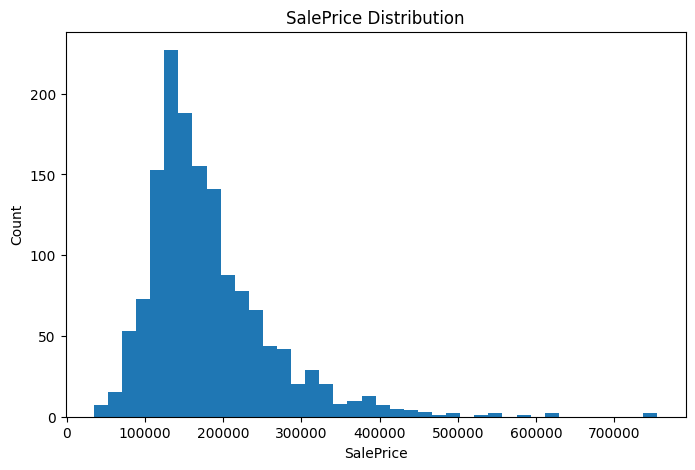

In [5]:

plt.figure(figsize=(8,5))
plt.hist(df["SalePrice"], bins=40)
plt.xlabel("SalePrice")
plt.ylabel("Count")
plt.title("SalePrice Distribution")
plt.show()

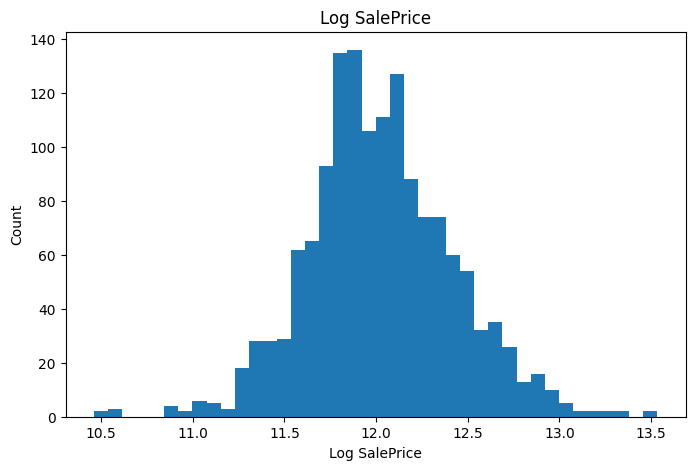

In [7]:
df["SalePrice_log"] = np.log1p(df["SalePrice"])
plt.figure(figsize=(8,5))
plt.hist(df["SalePrice_log"], bins=40)
plt.title("Log SalePrice")
plt.xlabel("Log SalePrice")
plt.ylabel("Count")
plt.show()

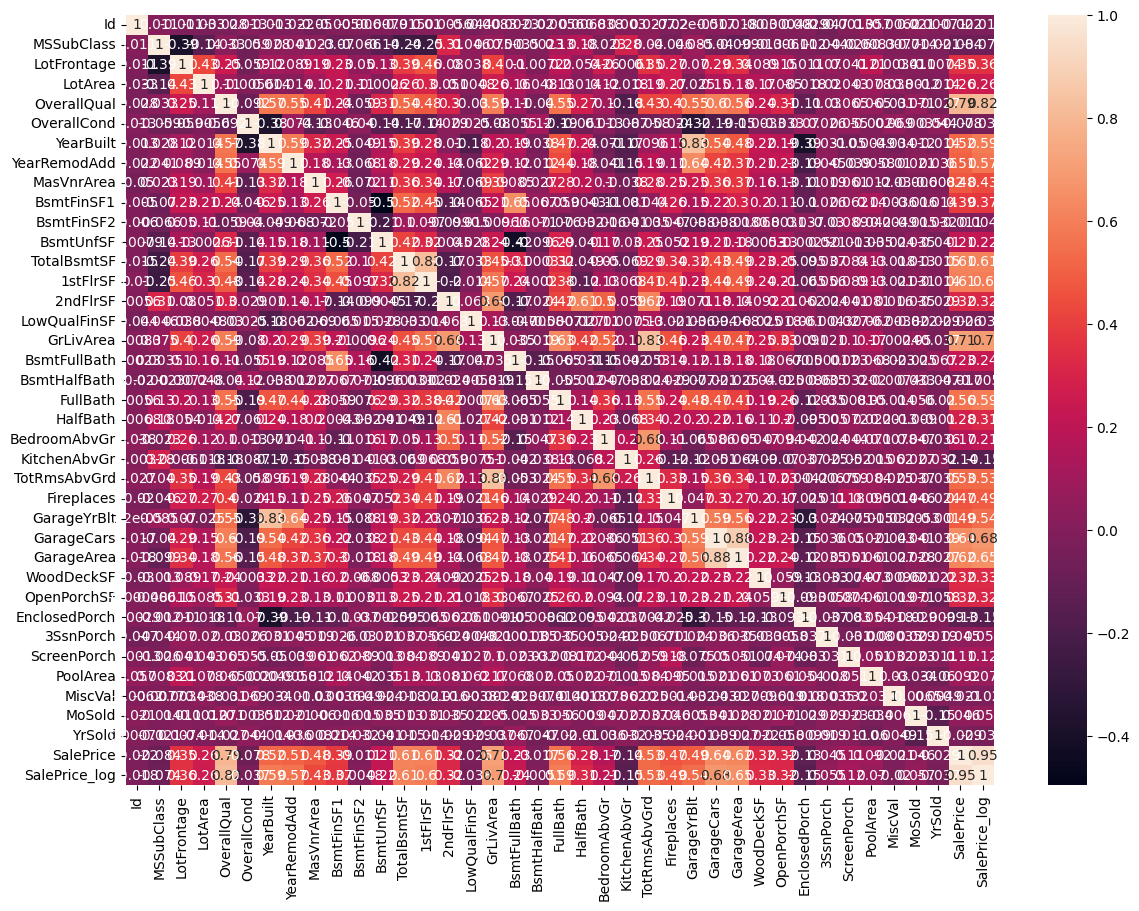

In [9]:
numeric_df = df.select_dtypes(include="number")
corr = numeric_df.corr()

plt.figure(figsize=(14,10))
sns.heatmap(corr, annot=True)
plt.show()

In [10]:
corr_sale = corr["SalePrice"].sort_values(ascending=False)
print(corr_sale.head(15))

SalePrice        1.000000
SalePrice_log    0.948374
OverallQual      0.790982
GrLivArea        0.708624
GarageCars       0.640409
GarageArea       0.623431
TotalBsmtSF      0.613581
1stFlrSF         0.605852
FullBath         0.560664
TotRmsAbvGrd     0.533723
YearBuilt        0.522897
YearRemodAdd     0.507101
GarageYrBlt      0.486362
MasVnrArea       0.477493
Fireplaces       0.466929
Name: SalePrice, dtype: float64


In [13]:
top_corr = corr["SalePrice"] \
    .sort_values(ascending=False) \
    .head(10)

print(top_corr)

SalePrice        1.000000
SalePrice_log    0.948374
OverallQual      0.790982
GrLivArea        0.708624
GarageCars       0.640409
GarageArea       0.623431
TotalBsmtSF      0.613581
1stFlrSF         0.605852
FullBath         0.560664
TotRmsAbvGrd     0.533723
Name: SalePrice, dtype: float64


<Axes: xlabel='GrLivArea', ylabel='SalePrice'>

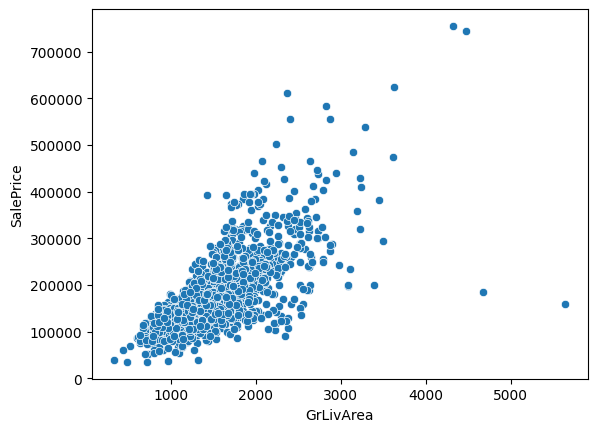

In [14]:
sns.scatterplot(
    data=df,
    x="GrLivArea",
    y="SalePrice"
)

In [15]:
outliers = df[
    (df["GrLivArea"] > 4000)
    &
    (df["SalePrice"] < 300000)
]

print(outliers.index)

RangeIndex(start=523, stop=2073, step=775)


([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24],
 [Text(0, 0, 'CollgCr'),
  Text(1, 0, 'Veenker'),
  Text(2, 0, 'Crawfor'),
  Text(3, 0, 'NoRidge'),
  Text(4, 0, 'Mitchel'),
  Text(5, 0, 'Somerst'),
  Text(6, 0, 'NWAmes'),
  Text(7, 0, 'OldTown'),
  Text(8, 0, 'BrkSide'),
  Text(9, 0, 'Sawyer'),
  Text(10, 0, 'NridgHt'),
  Text(11, 0, 'NAmes'),
  Text(12, 0, 'SawyerW'),
  Text(13, 0, 'IDOTRR'),
  Text(14, 0, 'MeadowV'),
  Text(15, 0, 'Edwards'),
  Text(16, 0, 'Timber'),
  Text(17, 0, 'Gilbert'),
  Text(18, 0, 'StoneBr'),
  Text(19, 0, 'ClearCr'),
  Text(20, 0, 'NPkVill'),
  Text(21, 0, 'Blmngtn'),
  Text(22, 0, 'BrDale'),
  Text(23, 0, 'SWISU'),
  Text(24, 0, 'Blueste')])

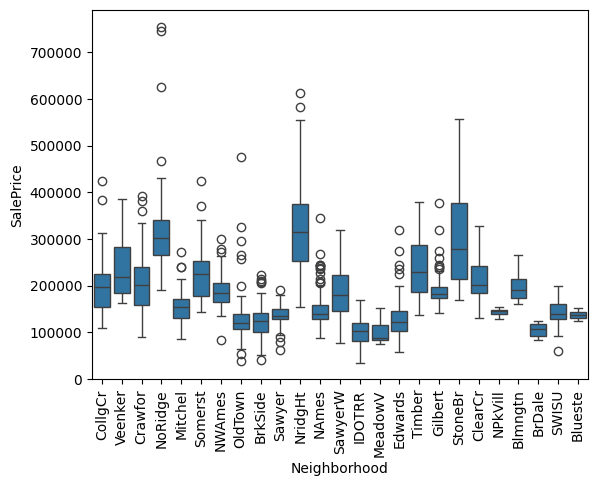

In [17]:
sns.boxplot(
    data=df,
    x="Neighborhood",
    y="SalePrice"
)
plt.xticks(rotation=90)
